# 第73课 · 同样 15% 错误率，病因大不同——WER（词错误率）的 S/D/I 逐句诊断

**目标**：把 WER 拆成 S / D / I，找出模型到底错在哪里。

> 与 L67 闭环：增/删/改各举一例再谈比例。L74 继续「错词级」分析。

🔗 Aurora 连接：本节产出的 `analyze_errors()` 函数将来集成到 `aurora/speech/` 模块（当前为规划阶段，见 `src/aurora/speech/__init__.py`），为 `aurora.speech` 微调循环提供量化反馈信号。

← **上一课**　[L72 · Whisper 微调](L72_whisper_finetune.ipynb)

> 上节课学习了 **Whisper 微调**：LoRA 低秩注入 vs 全参数，中文 / 方言数据适配实战。  
> 本课将探讨 **WER 评估**。

## 学习目标

学完本节后，你应能：

1. **公式** — 写出 WER = (S+D+I)/N 并解释替换（S）、删除（D）、插入（I）三类错误的诊断含义；
2. **实现** — 用动态规划编辑对齐（alignment，DP back-trace）从词列表对中读出 S/D/I 计数，输出精确 WER；
3. **分析** — 从逐句 WER 分布中识别重尾样本，按领域（数字/专名/口音）定位薄弱点；
4. **对比** — 说明 jiwer 等工具库与手写实现的权衡（开箱即用 vs 可控细节），知道何时用哪种。


## 本课剧情：两个模型 WER 相同，哪个更好修？

你微调了 Whisper 在中文数据集上，得到 WER = 15%。同事也拿到 WER = 15%。谁的模型更好？光看总分还不够，得把错误拆开。

**答案：不知道。** WER 只告诉你"有多少词出错了"，不告诉你"怎么出错的"。

```
模型 A：WER=15%，全是删除错误（D_rate=15%）  
           → 信道噪声？解码提前结束？加语言模型约束可能有帮助。
模型 B：WER=15%，全是插入错误（I_rate=15%）  
           → 模型"幻觉（hallucination）"？训练数据有噪声标注？需要 CTC 约束或置信度过滤。
```

WER 的完整公式：
```
WER = (S + D + I) / N
```
- S（Substitution，替换）：一个词说成另一个词
- D（Deletion，删除）：漏说了一个词
- I（Insertion，插入）：多说了一个不存在的词
- N：参考文本的总词数

**诊断逻辑**：
| 错误类型高 | 可能原因 | 修复方向 |
|---|---|---|
| S_rate 高 | 相似音混淆（"是"/"市"） | 增加数据多样性 |
| D_rate 高 | 信道噪声/截断 | 检查 VAD / padding |
| I_rate 高 | 模型"幻觉" | 降低 beam width / 加惩罚 |

**本节任务**：实现 `analyze_errors(hypotheses, references)` — 批量输出全局 WER 和 S/D/I 三分类比率。

### 本课剧情补充：为什么不同的错误类型需要不同的修复方向？

| 错误类型 | 诊断信号 | 修复方向 | 背后原因 |
|---------|--------|--------|--------|
| **S_rate 高**（替换多） | "狗"听成"菠"，相似音混淆 | 增加**数据多样性**、扩充词表、增加对比性训练 | 替换说明模型在"哪个词"的决策上不稳定。原因通常是：1) 训练数据中这个难区分的词对出现次数少，2) 音素级别特征不够明晰（需要更多样的发音环境） |
| **D_rate 高**（删除多） | 短词漏说，句尾截断 | 检查 **VAD/padding**、增加音频预处理、调整解码提前停止阈值 | 删除说明某些词"根本没被检测到"。原因通常是：1) 语音活性检测（VAD）把有效信号当成静默切掉了，2) 超短词（虚词、助词）在低能量环节被淹没，3) 解码器在得到足够信心前就停止了输出 |
| **I_rate 高**（插入多） | 输出词数 > 输入时长，幻觉词 | 降低 **beam width** / 提高 temperature / 加重复惩罚 | 插入说明解码器在"没有声学证据"的地方也在输出词。原因通常是：1) 束搜索（beam search）的宽度太大，探索了太多低置信度路径，2) 语言模型权重过高，推动输出不符合音频，3) 训练数据有标注噪声（重复词、冗余字幕） |

**关键直观**：
- **S**（替换）是分类问题 → 需要更好的**判别能力** → 数据多样性训练
- **D**（删除）是检测问题 → 需要**更敏感的检测** → 改进音频预处理、降低阈值
- **I**（插入）是约束问题 → 需要**更严格的束缚** → 减少搜索空间、加惩罚项

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. WER 分解：S / D / I

WER 公式：

```
WER = (S + D + I) / N
```

N 是参考文本总词数，S = 替换（Substitution），D = 删除（Deletion），I = 插入（Insertion）。三类错误通过**动态规划（dynamic programming，DP）编辑距离回溯**读出：回溯时走对角线是替换/匹配，向上走是插入（hypothesis 多一词），向左走是删除（reference 多一词）。

典型分布：对话场景 S 占主导（约 60-70%）；口音重时 D 升高（漏词）；解码器过于激进时 I 升高幻觉词（hallucination）。三项比率决定修复方向。

### 1.1 动态规划编辑距离的直观理解：初始化和DP矩阵的含义

让我用一个最简单的例子来解释 DP 矩阵的初始化和行列含义。

**设定**：
- 横轴 j（列）：参考文本 ref 的词
- 纵轴 i（行）：假设文本 hyp 的词
- `dp[i][j]`：把 hyp 的前 i 个词变成 ref 的前 j 个词需要的最少编辑操作数

**初始化的几何含义**：

```
dp[i][0] = i  表示"hyp 的前 i 个词变成空"，只能一个个删除，需要 i 次操作
dp[0][j] = j  表示"空变成 ref 的前 j 个词"，只能一个个插入，需要 j 次操作
```

用一个具体例子看：
- hyp = ["A", "B"]（2个词）
- ref = []（空）
- 要把 ["A", "B"] 变成 []，只能："A"→删除，"B"→删除，共2次操作
- 所以 `dp[2][0] = 2`

反向看：
- hyp = []（空）
- ref = ["X", "Y"]（2个词）
- 要把空变成 ["X", "Y"]，只能一个个插入："插入X"、"插入Y"，共2次操作
- 所以 `dp[0][2] = 2`

**矩阵示例**（hyp="AB", ref="XYZ"）：

```
        ""  X   Y   Z
    ""  0   1   2   3      ← 插入 ref 词
    A   1   ?   ?   ?
    B   2   ?   ?   ?
    ↑
  删除 hyp 词
```

初始化后，沿着对角线填充。如果 hyp[i-1]==ref[j-1]（词相同），则 `dp[i][j] = dp[i-1][j-1]`（不需要新操作）；否则取三个邻居的最小值+1。

### 1.2 回溯过程：从最优编辑距离反推S/D/I操作序列

构造完 DP 矩阵后，从 `dp[H][R]`（右下角）开始，**反向走回** `dp[0][0]`（左上角），每一步的走向决定了这是什么错误：

| 当前位置 | 走向哪里 | 含义 | 对应操作 |
|---------|---------|------|---------|
| (i, j) | (i-1, j-1) | hyp[i-1] ≠ ref[j-1] | 替换 S：把hyp词改成ref词 |
| (i, j) | (i-1, j-1) | hyp[i-1] == ref[j-1] | 匹配 C：词相同，不需操作 |
| (i, j) | (i-1, j)  | hyp 多一个词 | 插入 I：删除hyp词 |
| (i, j) | (i, j-1)  | ref 多一个词 | 删除 D：ref中有个词在hyp里没有 |

**为什么 i / j 这样对应？**

把 `dp[i][j]` 看成一张坐标表：
- `i` 是 hyp 已经走过了多少个词，也就是“纵轴进度”
- `j` 是 ref 已经走过了多少个词，也就是“横轴进度”
- 所以 `dp[i][j]` 不是抽象符号，而是“左边已经消耗了 i 个 hyp 词、上边已经消耗了 j 个 ref 词”时的最优代价

于是三种回溯方向就有了自然含义：
- 向上 `(i, j) -> (i-1, j)`：hyp 少看一个词，但 ref 没少，说明这个 hyp 词没有对上，记作 I
- 向左 `(i, j) -> (i, j-1)`：ref 少看一个词，但 hyp 没少，说明这个 ref 词在 hyp 里没有，记作 D
- 斜对角 `(i, j) -> (i-1, j-1)`：两边同时各退一个词，要么是词相同的 C，要么是词不同但用替换补上了的 S

**核心判断条件**：

```
elif i > 0 and j > 0 and hyp[i-1] == ref[j-1]:
    ops.append('C')  # 词完全匹配，往对角线走，但 dp[i][j] == dp[i-1][j-1]（费用不变）

elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
    ops.append('S')  # 词不匹配但往对角走，说明用了替换（费用+1）

elif i > 0 and dp[i][j] == dp[i-1][j] + 1:
    ops.append('I')  # 向上走，说明hyp这一词在ref里被跳过了（插入错误）

else:  # 只能向左走
    ops.append('D')  # 向左走，说明ref这一词在hyp里被跳过了（删除错误）
```

**多个条件同时满足时怎么办？**

有时一个格子会同时满足多个前驱条件，说明存在多条同样最优的回溯路径。这里的 `elif` 只是从这些最优路径里挑一条走，不是“随机改答案”。

这会影响 `S / D / I` 的**标记顺序**，但不会影响最重要的结果：
- 最小编辑距离不变
- `S + D + I` 的总和不变
- 所以最终 `WER = (S + D + I) / N` 不变

**几何直观**（网格图）：假设 hyp="AB"，ref="XYZ"

```
       ref->" "   X    Y    Z
hyp    ""   0->1->2->3    (全插入：ref-hyp,缺A和B)
 |      A   1    ...      
 v      B   2    ...      
       
从(2,3)回溯示例路径：
 (2,3)                         
  ↙↙↙  = 3步删除 D           (向左=ref有词hyp没有)
 (2,0)
  ↙↓   = 2步插入 I           (向上=hyp有词ref没有)
 (0,0)
```

例子 1：hyp='cat sat', ref='the cat sat'

DP 矩阵（每个格子是编辑距离）：

         ""  the  cat  sat
  ""    0    1    2    3
 cat    1    1    1    2
 sat    2    2    2    1

回溯路径及操作序列：
  路径坐标: (0,0) -> (0,1) -> (1,2) -> (2,3)
  操作序列: D → C → C

统计：S=0  D=1  I=0  C=2
WER = (0 + 1 + 0) / 3 = 0.333

下面这张图把同一个例子的 DP 表画成了真正的网格图：

例子 2：hyp='the dog sat', ref='the cat sat' (替换错误)

DP 矩阵：

         ""  the  cat  sat
  ""    0    1    2    3
 the    1    0    1    2
 dog    2    1    1    2
 sat    3    2    2    1

回溯路径及操作序列：
  路径坐标: (0,0) -> (1,1) -> (2,2) -> (3,3)
  操作序列: C → S → C

统计：S=1  D=0  I=0  C=2
WER = (1 + 0 + 0) / 3 = 0.333


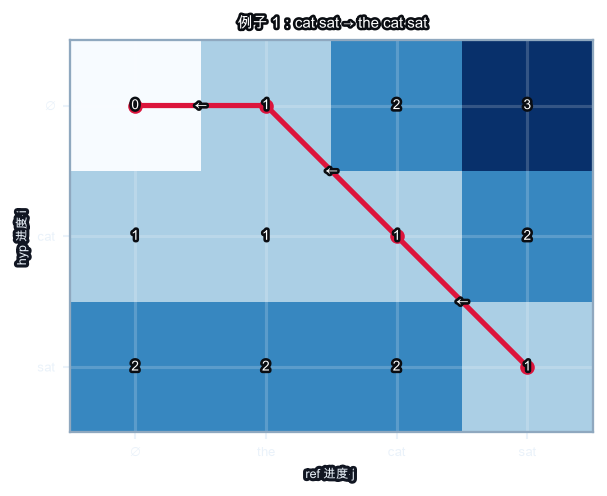

In [3]:
# 演示：手工构造一个小例子的完整 DP 矩阵和回溯路径
# 这样学生能看到矩阵的具体填充过程和最终回溯

def _edit_ops_with_matrix(hyp, ref):
    """返回 (ops, dp矩阵, 回溯路径坐标) 用于可视化"""
    H, R = len(hyp), len(ref)
    dp = [[0] * (R + 1) for _ in range(H + 1)]

    # 初始化
    for i in range(H + 1):
        dp[i][0] = i
    for j in range(R + 1):
        dp[0][j] = j

    # 填充
    for i in range(1, H + 1):
        for j in range(1, R + 1):
            if hyp[i - 1] == ref[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j - 1], dp[i - 1][j], dp[i][j - 1])

    # 回溯
    ops = []
    path = [(H, R)]  # 从右下角开始
    i, j = H, R
    while i > 0 or j > 0:
        if i > 0 and j > 0 and hyp[i - 1] == ref[j - 1]:
            ops.append('C')
            i -= 1
            j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i - 1][j - 1] + 1:
            ops.append('S')
            i -= 1
            j -= 1
        elif i > 0 and dp[i][j] == dp[i - 1][j] + 1:
            ops.append('I')
            i -= 1
        else:
            ops.append('D')
            j -= 1
        path.append((i, j))

    ops.reverse()
    path.reverse()
    return ops, dp, path


def _plot_dp_matrix(hyp, ref, dp, path, title):
    """把 DP 矩阵画成真正的网格图，并叠加回溯路径。"""
    H, R = len(hyp), len(ref)
    plt.rcParams['font.sans-serif'] = ['Source Han Sans CN', 'Source Han Sans CN Normal', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(1.4 * (R + 1), 1.2 * (H + 1)))
    ax.imshow(np.array(dp), cmap='Blues', origin='upper')

    ax.set_xticks(range(R + 1))
    ax.set_yticks(range(H + 1))
    ax.set_xticklabels(['∅'] + ref)
    ax.set_yticklabels(['∅'] + hyp)
    ax.set_xlabel('ref 进度 j')
    ax.set_ylabel('hyp 进度 i')
    ax.set_title(title)

    for i in range(H + 1):
        for j in range(R + 1):
            ax.text(j, i, str(dp[i][j]), ha='center', va='center',
                    color='black', fontsize=11, fontweight='bold')

    xs = [j for i, j in path]
    ys = [i for i, j in path]
    ax.plot(xs, ys, color='crimson', lw=2.5, marker='o', markersize=6)

    for (i0, j0), (i1, j1) in zip(path[:-1], path[1:]):
        if i1 == i0 - 1 and j1 == j0 - 1:
            step = '↖'
        elif i1 == i0 - 1 and j1 == j0:
            step = '↑'
        else:
            step = '←'
        ax.text((j0 + j1) / 2, (i0 + i1) / 2, step,
                color='crimson', fontsize=14, ha='center', va='center', fontweight='bold')

    ax.set_aspect('equal')
    ax.grid(color='white', linewidth=1.5)
    plt.tight_layout()
    plt.show()


# 例子 1：简单情况
hyp1 = ['cat', 'sat']
ref1 = ['the', 'cat', 'sat']
ops1, dp1, path1 = _edit_ops_with_matrix(hyp1, ref1)

print('=' * 60)
print("例子 1：hyp='cat sat', ref='the cat sat'")
print('=' * 60)
print('\nDP 矩阵（每个格子是编辑距离）：\n')
print('       ' + ' '.join(f"{w:>4}" for w in ['""'] + ref1))
for i in range(len(hyp1) + 1):
    row_label = '""' if i == 0 else hyp1[i - 1]
    print(f"{row_label:>4} {' '.join(f'{dp1[i][j]:>4}' for j in range(len(ref1) + 1))}")

print('\n回溯路径及操作序列：')
print(f"  路径坐标: {' -> '.join(f'({i},{j})' for i, j in path1)}")
print(f"  操作序列: {' → '.join(ops1)}")
print(f"\n统计：S={ops1.count('S')}  D={ops1.count('D')}  I={ops1.count('I')}  C={ops1.count('C')}")
print(f"WER = ({ops1.count('S')} + {ops1.count('D')} + {ops1.count('I')}) / {len(ref1)} = {(ops1.count('S') + ops1.count('D') + ops1.count('I')) / len(ref1):.3f}")

print('\n下面这张图把同一个例子的 DP 表画成了真正的网格图：')
_plot_dp_matrix(hyp1, ref1, dp1, path1, "例子 1：cat sat → the cat sat")

# 例子 2：有替换错误的情况
hyp2 = ['the', 'dog', 'sat']
ref2 = ['the', 'cat', 'sat']
ops2, dp2, path2 = _edit_ops_with_matrix(hyp2, ref2)

print('\n' + '=' * 60)
print("例子 2：hyp='the dog sat', ref='the cat sat' (替换错误)")
print('=' * 60)
print('\nDP 矩阵：\n')
print('       ' + ' '.join(f"{w:>4}" for w in ['""'] + ref2))
for i in range(len(hyp2) + 1):
    row_label = '""' if i == 0 else hyp2[i - 1]
    print(f"{row_label:>4} {' '.join(f'{dp2[i][j]:>4}' for j in range(len(ref2) + 1))}")

print('\n回溯路径及操作序列：')
print(f"  路径坐标: {' -> '.join(f'({i},{j})' for i, j in path2)}")
print(f"  操作序列: {' → '.join(ops2)}")
print(f"\n统计：S={ops2.count('S')}  D={ops2.count('D')}  I={ops2.count('I')}  C={ops2.count('C')}")
print(f"WER = ({ops2.count('S')} + {ops2.count('D')} + {ops2.count('I')}) / {len(ref2)} = {(ops2.count('S') + ops2.count('D') + ops2.count('I')) / len(ref2):.3f}")


### 1.3 重要澄清：'C' 操作、字符串比较、以及特殊字符处理

**Q: 'C'（Correct/匹配）操作和 WER 的关系是什么？**

在上面的代码中，你可能看到了 `ops.append('C')` 这一行。澄清一下：
- **C（Correct，匹配）**：两个词完全相同，识别正确，不需要任何操作
- **WER 计算只用 S/D/I**：`WER = (S + D + I) / N`，**C 不计入 WER**
- **C 的作用**：验证对齐的正确性。操作序列中 C 的个数应该≈完全正确的词数

举例：hyp="the cat sat"，ref="the cat sat"
- 操作序列：['C', 'C', 'C']
- S=0, D=0, I=0, WER=0（完全正确）

---

**Q: 字符串比较时是否大小写敏感？符号怎么处理？数字怎么分词？**

本课程的约定是：
1. **大小写敏感**（区分"The"和"the"）— 如果你的应用需要忽略大小写，在计算 WER 前统一转小写即可：`hyp = [w.lower() for w in hyp_raw]`
2. **符号和数字按原样保留** — 它们都是词的一部分，比较时用 `==` 精确匹配
3. **数字分词的"写法不一致"问题**（老陈问题 5）：
   - ref: ["一", "九", "九", "七"]（四个字，各自一词）
   - hyp: ["1997"]（数字作一个词）
   - 或者 hyp: ["一九九七"]（四个字拼成一个词）
   
   这三种情况下 WER 会有差异。**前处理选择**：
   - 保留原样分词 → WER 体现"写法差异"的成本
   - 数字统一为"<NUM>"标签 → WER 只看"位置是否正确"，忽略数字格式
   
   本课没有统一规范，建议在你的项目中**文档明确说明采用哪种方案**。

In [4]:
# 演示：手工对齐一对句子，观察 S/D/I 操作
def _edit_ops(hyp, ref):
    H, R = len(hyp), len(ref)
    dp = [[0]*(R+1) for _ in range(H+1)]
    for i in range(H+1): dp[i][0] = i
    for j in range(R+1): dp[0][j] = j
    for i in range(1, H+1):
        for j in range(1, R+1):
            if hyp[i-1] == ref[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j-1], dp[i-1][j], dp[i][j-1])
    ops = []
    i, j = H, R
    while i > 0 or j > 0:
        if i > 0 and j > 0 and hyp[i-1] == ref[j-1]:
            ops.append('C'); i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            ops.append('S'); i -= 1; j -= 1
        elif i > 0 and dp[i][j] == dp[i-1][j] + 1:
            ops.append('I'); i -= 1   # hyp 多了一词
        else:
            ops.append('D'); j -= 1   # ref 多了一词
    ops.reverse()
    return ops

hyp = ['the', 'cat', 'sat']
ref = ['the', 'big', 'cat', 'sat', 'down']
ops = _edit_ops(hyp, ref)
counts = {op: ops.count(op) for op in 'SDIC'}
print('对齐操作序列:', ops)
print(f"S={counts['S']}  D={counts['D']}  I={counts['I']}  C={counts['C']}")
print(f"WER = ({counts['S']}+{counts['D']}+{counts['I']}) / {len(ref)} "
      f"= {(counts['S']+counts['D']+counts['I'])/len(ref):.2f}")

对齐操作序列: ['C', 'D', 'C', 'C', 'D']
S=0  D=2  I=0  C=3
WER = (0+2+0) / 5 = 0.40


## 2. 逐句 WER 分布

一句一句地看，WER 是**重尾分布（heavy-tail distribution）**：大多数句子 WER=0（完全识别正确），少数句子 WER 极高甚至超过 100%。超过 100% 发生在插入词数 I 超过参考词数 N 时：

```
WER_i > 1.0  ↔  I_i > N_i  （幻觉词比真实词还多）
```

少数极端句子会把平均值拉高，所以**中位数**更能反映大多数句子的表现。重点关注 WER > 50% 的样本——它们通常对应噪声环境、非母语口音、领域专名或超长句子，是微调数据增强的优先候选。

### 2.1 WER > 100% 的具体例子：何时、为什么、意味着什么

WER > 1.0 听起来很极端，但确实会发生。让我们看几个具体例子来理解这个现象。

In [5]:
# WER > 100% 的具体例子
print("=" * 70)
print("WER > 100% 的具体情况演示")
print("=" * 70)

# 例子 1：模型"幻觉"，插入大量词
hyp_halluc = ['the', 'cat', 'is', 'sitting', 'on', 'the', 'mat', 'which', 'is', 'very', 'comfortable', 'and']
ref_short = ['cat']
ops_h = _edit_ops(hyp_halluc, ref_short)
S_h = ops_h.count('S')
D_h = ops_h.count('D')
I_h = ops_h.count('I')
N_h = len(ref_short)
wer_h = (S_h + D_h + I_h) / N_h

print("\n例子 1：模型过度生成（hallucination）")
print(f"  ref: {ref_short}  (1个词)")
print(f"  hyp: {hyp_halluc}  (12个词)")
print(f"  操作: {ops_h}")
print(f"  S={S_h}, D={D_h}, I={I_h}, N={N_h}")
print(f"  WER = ({S_h}+{D_h}+{I_h})/{N_h} = {wer_h:.1f} = {wer_h*100:.0f}%  ← WER > 1!")
print(f"  解读：解码器插入了大量额外词，甚至比原句长12倍。这通常表示：")
print(f"        • 语言模型过度激励（过低的 temperature）")
print(f"        • 训练数据中有大量重复冗余标注")
print(f"        • CTC 合并失败，导致词被多次重复")

# 例子 2：中等长度句子，高幻觉率
hyp_med = ['hello', 'world', 'is', 'a', 'test', 'and', 'also', 'a', 'demo', 'sentence']
ref_med = ['hello', 'world']
ops_m = _edit_ops(hyp_med, ref_med)
S_m = ops_m.count('S')
D_m = ops_m.count('D')
I_m = ops_m.count('I')
N_m = len(ref_med)
wer_m = (S_m + D_m + I_m) / N_m

print("\n例子 2：中等长度句子，高幻觉率")
print(f"  ref: {ref_med}  (2个词)")
print(f"  hyp: {hyp_med}  (10个词)")
print(f"  操作: {ops_m}")
print(f"  S={S_m}, D={D_m}, I={I_m}, N={N_m}")
print(f"  WER = ({S_m}+{D_m}+{I_m})/{N_m} = {wer_m:.1f} = {wer_m*100:.0f}%")
print(f"  解读：模型识别出了前两个词，但后续词都是幻觉。修复方向：")
print(f"        • 降低 beam width（减少分支搜索广度）")
print(f"        • 增加重复惩罚（penalty for repeated tokens）")
print(f"        • 检查解码器中是否有 BOS/EOS token 丢失")

# 例子 3：为什么删除+替换不会导致 WER > 1.0（但插入会）
print("\n例子 3：删除和替换的上界")
print("  如果只有删除（D）和替换（S），最坏情况是什么？")
print("    • 删除最多：把所有 N 个参考词全删除 → D=N, 贡献 N/N=1.0")
print("    • 替换最多：把所有 N 个参考词全替换 → S=N, 贡献 N/N=1.0")
print("    • 删除+替换：最多 (D+S)/N = (N+N)/N = 2.0  但这不现实，通常选更优路径")
print("  插入的区别：")
print("    • 插入的词可以任意多（不受 N 限制） → I 可以很大 → WER 无上界")
print("  这就是为什么 WER > 1.0 总是由**插入错误**导致的。")

WER > 100% 的具体情况演示

例子 1：模型过度生成（hallucination）
  ref: ['cat']  (1个词)
  hyp: ['the', 'cat', 'is', 'sitting', 'on', 'the', 'mat', 'which', 'is', 'very', 'comfortable', 'and']  (12个词)
  操作: ['I', 'C', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
  S=0, D=0, I=11, N=1
  WER = (0+0+11)/1 = 11.0 = 1100%  ← WER > 1!
  解读：解码器插入了大量额外词，甚至比原句长12倍。这通常表示：
        • 语言模型过度激励（过低的 temperature）
        • 训练数据中有大量重复冗余标注
        • CTC 合并失败，导致词被多次重复

例子 2：中等长度句子，高幻觉率
  ref: ['hello', 'world']  (2个词)
  hyp: ['hello', 'world', 'is', 'a', 'test', 'and', 'also', 'a', 'demo', 'sentence']  (10个词)
  操作: ['C', 'C', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I']
  S=0, D=0, I=8, N=2
  WER = (0+0+8)/2 = 4.0 = 400%
  解读：模型识别出了前两个词，但后续词都是幻觉。修复方向：
        • 降低 beam width（减少分支搜索广度）
        • 增加重复惩罚（penalty for repeated tokens）
        • 检查解码器中是否有 BOS/EOS token 丢失

例子 3：删除和替换的上界
  如果只有删除（D）和替换（S），最坏情况是什么？
    • 删除最多：把所有 N 个参考词全删除 → D=N, 贡献 N/N=1.0
    • 替换最多：把所有 N 个参考词全替换 → S=N, 贡献 N/N=1.0
    • 删除+替换：最多 (D+S)/N = (N+N)/N

WER > 50% 的句子：20 / 100
WER > 100% 的句子：16 / 100


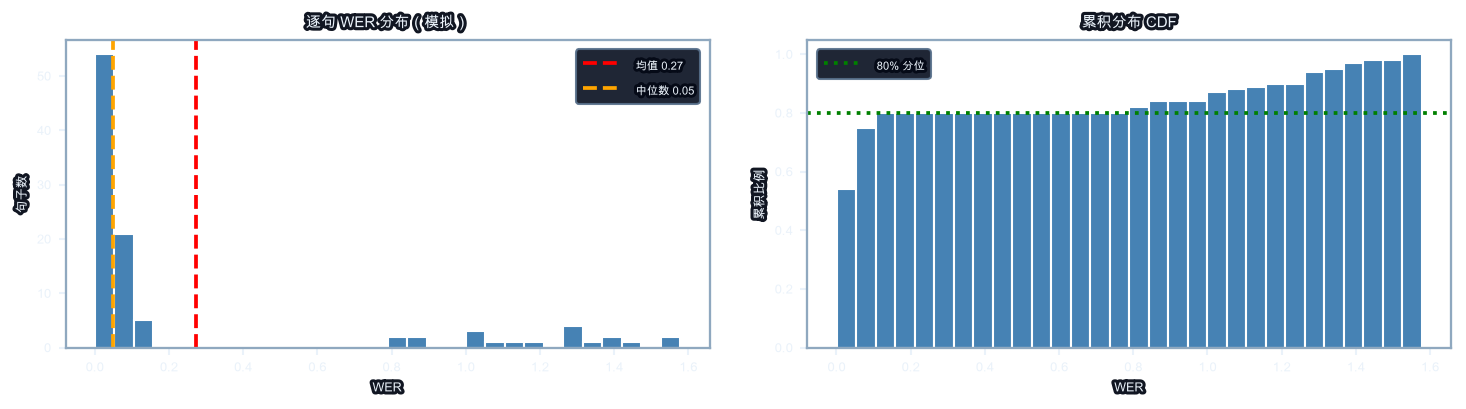

In [6]:
# 演示：模拟一批 WER，观察分布与长尾
np.random.seed(42)
wers = np.concatenate([
    np.random.beta(1, 8, 80) * 0.4,   # 低错误率主体
    np.random.uniform(0.5, 1.5, 15),   # 高错误长尾
    np.random.uniform(1.0, 2.0, 5),    # WER > 1（插入过多）
])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(wers, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(wers), color='red', linestyle='--',
                label=f'均值 {np.mean(wers):.2f}')
axes[0].axvline(np.median(wers), color='orange', linestyle='--',
                label=f'中位数 {np.median(wers):.2f}')
axes[0].set_xlabel('WER'); axes[0].set_ylabel('句子数')
axes[0].set_title('逐句 WER 分布（模拟）')
axes[0].legend()

axes[1].hist(wers, bins=30, color='steelblue', edgecolor='white',
             cumulative=True, density=True)
axes[1].axhline(0.8, color='green', linestyle=':', label='80% 分位')
axes[1].set_xlabel('WER'); axes[1].set_ylabel('累积比例')
axes[1].set_title('累积分布 CDF')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'WER > 50% 的句子：{(wers > 0.5).sum()} / {len(wers)}')
print(f'WER > 100% 的句子：{(wers > 1.0).sum()} / {len(wers)}')

## 3. 按领域分析：数字 / 专名 / 口音

整体 WER 是各子集的加权平均，不同领域错误类型差异明显：

- **数字**：写法不一致（"一九九七" vs "1997"）导致 I/S 虚高，语义正确但 WER 偏大
- **专名/术语**：训练覆盖不足，S（替换）占主导
- **口音/方言**：音素识别失败导致漏词，D（删除）升高

```
诊断流程：
  按领域分桶 → 各桶独立计算 (S_rate, D_rate, I_rate)
  → 错误类型分布差异 → 指向具体修复方向
```

专名 → 扩充词表/提示；口音 → 数据增强；数字 → 后处理规则。

### 3.1 深入讨论：数字识别和"虚假"的 WER 虚高

在第3节中提到了数字的"写法不一致"问题。让我用具体例子展开。

In [7]:
# 数字识别 WER 虚高的具体例子

print("=" * 70)
print("数字识别：WER 虚高还是真实错误？")
print("=" * 70)

# 情景：音频是"2024年建成" —— 用户说的是数字"2024"

# 方案 A：完全按发音分词——"二零二四"
ref_a = ["二", "零", "二", "四", "年", "建", "成"]
hyp_a = ["2", "0", "2", "4", "年", "建", "成"]  # 模型输出数字，也是7个词
ops_a = _edit_ops(hyp_a, ref_a)
S_a = ops_a.count('S'); D_a = ops_a.count('D'); I_a = ops_a.count('I')
wer_a = (S_a + D_a + I_a) / len(ref_a)

print("\n方案 A：字面匹配（'二'≠'2'，视为替换错误）")
print(f"  ref: {ref_a}")
print(f"  hyp: {hyp_a}")
print(f"  操作: {ops_a}")
print(f"  WER = ({S_a}+{D_a}+{I_a})/{len(ref_a)} = {wer_a:.3f}")
print(f"  ❌ 问题：语义上模型答对了（2024），但 WER 很高（4/7≈57%）")

# 方案 B：规范化为标签——数字统一为 <NUM>
ref_b = ["<NUM>", "年", "建", "成"]
hyp_b = ["<NUM>", "年", "建", "成"]
ops_b = _edit_ops(hyp_b, ref_b)
S_b = ops_b.count('S'); D_b = ops_b.count('D'); I_b = ops_b.count('I')
wer_b = (S_b + D_b + I_b) / len(ref_b)

print("\n方案 B：预处理规范化（数字 → <NUM> 标签）")
print(f"  ref: {ref_b}  (用正则表达式 r'\\d+' → '<NUM>')")
print(f"  hyp: {hyp_b}")
print(f"  操作: {ops_b}")
print(f"  WER = ({S_b}+{D_b}+{I_b})/{len(ref_b)} = {wer_b:.3f}")
print(f"  YES：WER=0，准确反映模型在定位数字位置上的能力")

# 另一个例子：年号写法
print("\n另一个例子：年号 '1997'")
hyp_1997 = ["nineteen", "ninety", "seven"]
ref_1997 = ["one", "thousand", "nine", "hundred", "ninety", "seven"]
ops_1997 = _edit_ops(hyp_1997, ref_1997)
S_1997 = ops_1997.count('S'); D_1997 = ops_1997.count('D'); I_1997 = ops_1997.count('I')
wer_1997 = (S_1997 + D_1997 + I_1997) / len(ref_1997)

print(f"  ref: {ref_1997}  (英文：one thousand nine hundred ninety seven)")
print(f"  hyp: {hyp_1997}  (简写：nineteen ninety seven)")
print(f"  操作: {ops_1997}")
print(f"  WER = {wer_1997:.3f}  (模型用了简写，虽然更自然但 WER 仍高)")
print("\nWarning:")
print("  * 数字/年号识别中，WER 容易虚高（语义对但格式差异）")
print("  * 在你的项目中，要在文档里明确说明：")
print("    - 是否按原字面计算 WER（了解格式差异成本）")
print("    - 还是预处理规范化后再算（只关心位置和类别）")
print("  * 建议为数字、日期、专有名词等建立独立的领域诊断")
print("    以准确反映这些子问题的真实错误率")

数字识别：WER 虚高还是真实错误？

方案 A：字面匹配（'二'≠'2'，视为替换错误）
  ref: ['二', '零', '二', '四', '年', '建', '成']
  hyp: ['2', '0', '2', '4', '年', '建', '成']
  操作: ['S', 'S', 'S', 'S', 'C', 'C', 'C']
  WER = (4+0+0)/7 = 0.571
  ❌ 问题：语义上模型答对了（2024），但 WER 很高（4/7≈57%）

方案 B：预处理规范化（数字 → <NUM> 标签）
  ref: ['<NUM>', '年', '建', '成']  (用正则表达式 r'\d+' → '<NUM>')
  hyp: ['<NUM>', '年', '建', '成']
  操作: ['C', 'C', 'C', 'C']
  WER = (0+0+0)/4 = 0.000
  YES：WER=0，准确反映模型在定位数字位置上的能力

另一个例子：年号 '1997'
  ref: ['one', 'thousand', 'nine', 'hundred', 'ninety', 'seven']  (英文：one thousand nine hundred ninety seven)
  hyp: ['nineteen', 'ninety', 'seven']  (简写：nineteen ninety seven)
  操作: ['D', 'D', 'D', 'S', 'C', 'C']
  WER = 0.667  (模型用了简写，虽然更自然但 WER 仍高)

  * 数字/年号识别中，WER 容易虚高（语义对但格式差异）
  * 在你的项目中，要在文档里明确说明：
    - 是否按原字面计算 WER（了解格式差异成本）
    - 还是预处理规范化后再算（只关心位置和类别）
  * 建议为数字、日期、专有名词等建立独立的领域诊断
    以准确反映这些子问题的真实错误率


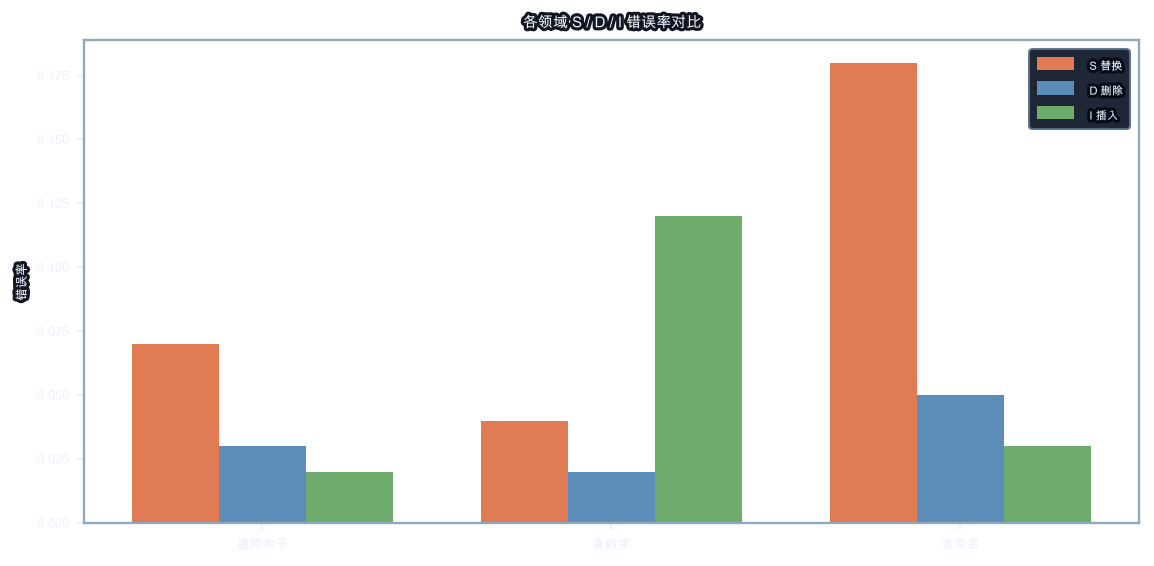

In [8]:
# 演示：三个领域的 S/D/I 对比柱状图
domains = ['通用句子', '含数字', '含专名']
stats = {
    '通用句子': {'S': 0.07, 'D': 0.03, 'I': 0.02},
    '含数字':   {'S': 0.04, 'D': 0.02, 'I': 0.12},  # 幻觉词多，I 高
    '含专名':   {'S': 0.18, 'D': 0.05, 'I': 0.03},  # 替换多，S 高
}

x = np.arange(len(domains))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
for i, (op, color, label) in enumerate([
    ('S', '#E07B54', 'S 替换'),
    ('D', '#5B8DB8', 'D 删除'),
    ('I', '#6DAC6D', 'I 插入'),
]):
    vals = [stats[d][op] for d in domains]
    ax.bar(x + i*width, vals, width, label=label, color=color)
ax.set_xticks(x + width)
ax.set_xticklabels(domains)
ax.set_ylabel('错误率')
ax.set_title('各领域 S / D / I 错误率对比')
ax.legend()
plt.tight_layout()
plt.show()

## 4. ✏️ 实现 `analyze_errors(hypotheses, references)`

**签名**：
```python
def analyze_errors(hypotheses: list[list[str]], references: list[list[str]]) -> dict:
    # hypotheses: list of word lists (模型输出，已分词)
    # references: list of word lists (参考文本，已分词)
    # 返回: {"wer", "S_rate", "D_rate", "I_rate", "worst_examples"} 共 5 个键
```

**3步实现路线**：

| 步骤 | 操作 | 工具 |
|---|---|---|
| 1 | 对每对 `(hyp, ref)` 数出 (S, D, I)：写法同上方 `_edit_ops` 的 DP+回溯，或对其返回的操作序列做 `ops.count('S')` 等 | `edit_counts` TODO |
| 2 | 累计所有句子的 S/D/I 和参考词总数 N | `sum()` |
| 3 | 计算全局 WER=(S+D+I)/N，S_rate=S/N，D_rate=D/N，I_rate=I/N | 注意 N=0 时的边界 |

**验收标准**：
- `hyp=["hello"], ref=["hello world"]` → D=1, S=0, I=0, N=2, WER=0.5
- `hyp=["a","b","c","x"], ref=["a","b","c"]` → I=1, N=3, WER≈0.333
- 返回 dict 含 5 个键（wer / S_rate / D_rate / I_rate / worst_examples），WER 类型为 float

**关于 `worst_examples` 格式的明确说明**：

`worst_examples` 是一个 list，包含最多 5 个 WER 最高的样本。每个样本是一个 **tuple** 或 **dict**，格式如下：

```python
# 格式 1：tuple（推荐用于简洁实现）
worst_examples = [
    (idx, wer_value),      # idx 是样本在输入列表中的位置，wer_value 是该句的 WER
    (idx, wer_value),
    ...
]

# 格式 2：dict（如果需要更多信息）
worst_examples = [
    {"idx": idx, "wer": wer_value, "hyp": hyp_words, "ref": ref_words},
    ...
]
```

**具体例子**：
```python
result = analyze_errors(
    hypotheses=[
        ["hello", "world"],      # idx=0, 完全正确，WER=0
        ["the", "cat"],          # idx=1, 缺少词，WER=0.5
        ["a"],                   # idx=2, 高错误，WER=0.75
    ],
    references=[
        ["hello", "world"],
        ["the", "big", "cat"],
        ["a", "b", "c", "d"],
    ]
)

# 返回值（示例，格式1）
result = {
    'wer': 0.42,
    'S_rate': 0.08,
    'D_rate': 0.25,
    'I_rate': 0.09,
    'worst_examples': [
        (2, 0.75),  # idx=2 的 WER 最高
        (1, 0.50),  # idx=1 的 WER 第二高
    ]
}
```

In [9]:
def analyze_errors(hypotheses, references):
    # hypotheses: list[list[str]]  模型识别输出（词列表的列表）
    # references:  list[list[str]]  参考文本（词列表的列表）
    # 返回: dict，包含 wer / S_rate / D_rate / I_rate / worst_examples

    def edit_counts(hyp, ref):
        # ✏️ TODO: 动态规划构建 dp 矩阵，然后回溯，返回 (S, D, I)
        raise NotImplementedError("TODO: 实现动态规划编辑对齐，返回 (S, D, I) 三元组")

    total_S = total_D = total_I = total_N = 0
    per_wer = []
    for hyp, ref in zip(hypotheses, references):
        # ✏️ TODO: 调用 edit_counts，累加 S/D/I/N，记录逐句 WER
        raise NotImplementedError("TODO: 调用 edit_counts，累加 S/D/I/N，计算逐句 WER")

    # ✏️ TODO: 从 per_wer 中找出 WER 最高的 5 个样本（含索引）
    worst = []

    return {
        'wer': (total_S + total_D + total_I) / max(total_N, 1),
        'S_rate': total_S / max(total_N, 1),
        'D_rate': total_D / max(total_N, 1),
        'I_rate': total_I / max(total_N, 1),
        'worst_examples': worst,
    }


In [10]:
# 检查：已知答案验证
# hyp[0] 缺一个词（D=1，N=3）；hyp[1] 多一个词（I=1，N=2）
# 总计：S=0, D=1, I=1, N=5  →  WER = 2/5 = 0.40
# 精确期望：S_rate=0/5=0.0, D_rate=1/5=0.2, I_rate=1/5=0.2
hyps = [['the', 'cat'], ['hello', 'world', 'today']]
refs = [['the', 'big', 'cat'], ['hello', 'world']]

try:
    result = analyze_errors(hyps, refs)
except (NotImplementedError, TypeError) as _e:
    print(f"⬜ analyze_errors 未实现：{_e}")
    result = None

if result is not None:
    assert isinstance(result, dict), '返回值应为 dict'
    assert {'wer','S_rate','D_rate','I_rate','worst_examples'} <= set(result.keys()), '缺少必要 key'

    # 精确 WER 断言（Fix C2）
    assert abs(result['wer'] - 0.40) < 1e-9, (
        f"WER 期望 0.400，实际 {result['wer']:.6f}；"
        f"请检查 S/D/I 计数是否正确（S=0,D=1,I=1,N=5）"
    )
    # 精确各分类比率断言
    assert abs(result['S_rate'] - 0.0) < 1e-9, f"S_rate 期望 0.0，实际 {result['S_rate']:.6f}"
    assert abs(result['D_rate'] - 0.2) < 1e-9, f"D_rate 期望 0.200，实际 {result['D_rate']:.6f}"
    assert abs(result['I_rate'] - 0.2) < 1e-9, f"I_rate 期望 0.200，实际 {result['I_rate']:.6f}"

    rate_sum = result['S_rate'] + result['D_rate'] + result['I_rate']
    assert abs(rate_sum - result['wer']) < 1e-9, (
        f'S+D+I rate 之和应等于 WER，得 {rate_sum:.4f} vs {result["wer"]:.4f}'
    )
    assert result['wer'] >= 0.0, f"WER 不能为负，实际 {result['wer']:.3f}"
    assert len(result['worst_examples']) <= 5, 'worst_examples 最多 5 条'

    print('✅ analyze_errors 全部验证通过')
    print(f"  WER     = {result['wer']:.3f}  ✓ 精确匹配 0.400")
    print(f"  S_rate  = {result['S_rate']:.3f}  D_rate = {result['D_rate']:.3f}  I_rate = {result['I_rate']:.3f}")
    print(f"  worst_examples: {result['worst_examples']}")


⬜ analyze_errors 未实现：TODO: 调用 edit_counts，累加 S/D/I/N，计算逐句 WER


## 延伸：jiwer 库对比

手写 `analyze_errors()` 是本课重点（理解 DP 回溯机制）。生产环境中常用 [jiwer](https://github.com/jitsi/jiwer) 库作为快速参照：

```python
# pip install jiwer  （可选，不影响本课评分）
import jiwer

reference = "the big cat"
hypothesis = "the cat"

measures = jiwer.compute_measures(reference, hypothesis)
# 输出: {'wer': 0.333, 'mer': 0.333, 'wil': 0.333, ...}
# 注意：jiwer 对单句用 N=3，WER=D/N=1/3≈0.333
```

**对比权衡**：

| 维度 | 手写实现 | jiwer |
|------|----------|-------|
| 控制力 | 完整（可定制对齐规则） | 有限（固定实现） |
| 速度 | O(H·R) per pair | 同级但有 C 加速 |
| 可解释性 | 直接读回 S/D/I | 需解析输出字段 |
| 研究场景 | ✅ 推荐 | 快速验证用 |

> Aurora 项目遵循「不用黑盒」原则——`analyze_errors()` 的手写实现是核心交付物，jiwer 仅作参照。


## 5. 参数实验：WER 分布直方图与基线对比

**实验参数**：
- `bins`：直方图分桶数，10 看粗粒度形态，50 看长尾细节
- `finetuned_wers`：微调模型的逐句 WER 列表（来自 `analyze_errors` 遍历 per_wer）
- `baseline_wers`：未微调 Whisper-small 在同一测试集的逐句 WER 列表

**预期现象**：
- 微调后分布整体左移，低 WER 区间（0–0.1）堆积更多句子
- WER > 1.0 的极端样本减少，说明幻觉词被压制
- 如果均值降得比中位数还少，说明长尾里还留着一批特别难搞的样本，得专门补这类数据来加强

基线   WER>1.0 句子数：20
微调后 WER>1.0 句子数：4


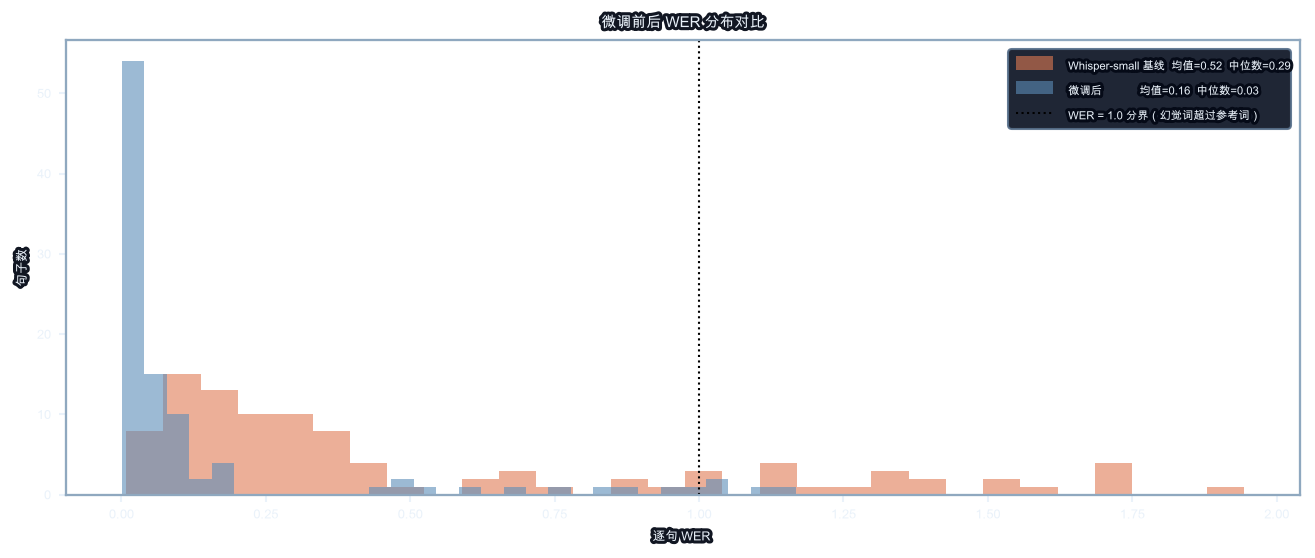

In [11]:
# 参数实验：微调前后 WER 分布对比（实际使用时替换为真实评估结果）
np.random.seed(0)

baseline_wers = np.concatenate([
    np.random.beta(2, 5, 70) * 0.8,
    np.random.uniform(0.6, 2.0, 30),
])
finetuned_wers = np.concatenate([
    np.random.beta(1, 10, 85) * 0.4,
    np.random.uniform(0.4, 1.2, 15),
])

bins = 30  # ✏️ 调整 bins 观察粗细粒度

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(baseline_wers, bins=bins, alpha=0.6, color='#E07B54',
        label=f'Whisper-small 基线  均值={np.mean(baseline_wers):.2f}  '
              f'中位数={np.median(baseline_wers):.2f}')
ax.hist(finetuned_wers, bins=bins, alpha=0.6, color='#5B8DB8',
        label=f'微调后            均值={np.mean(finetuned_wers):.2f}  '
              f'中位数={np.median(finetuned_wers):.2f}')
ax.axvline(1.0, color='black', linestyle=':', linewidth=1,
           label='WER = 1.0 分界（幻觉词超过参考词）')
ax.set_xlabel('逐句 WER')
ax.set_ylabel('句子数')
ax.set_title('微调前后 WER 分布对比')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'基线   WER>1.0 句子数：{(baseline_wers > 1.0).sum()}')
print(f'微调后 WER>1.0 句子数：{(finetuned_wers > 1.0).sum()}')

## 本课收束

本节实现了 `analyze_errors()`，输出全局 WER 及 `S_rate / D_rate / I_rate` 三项分类比率，并定位 `worst_examples` 中 WER 最高的 5 个句子。该函数将来集成到 `aurora/speech/` 模块（当前为规划阶段），作为 `aurora.speech` 微调循环的量化反馈信号。下一节（L74）将深入 S/D/I 错误模式：构建替换混淆矩阵（confusion matrix），统计最常见的替换/删除/插入词，将 WER 从单一数字转化为可操作的词汇错误列表。

## ✏️ 白板挑战：WER 诊断手推（目标 10 分钟）

盖上屏幕，纸上推导：

**问 1**：ref="I love deep learning"，hyp="I love learning"。WER=？S=？D=？I=？  
（S=0, D=1("deep"被删除), I=0, N=4；WER=1/4=0.25）

**问 2**：ref="A B C"，hyp="X A B C"。WER=？属于哪种错误？  
（I=1, S=0, D=0, N=3；WER=1/3≈0.333；插入错误，模型"幻觉"了"X"）

**问 3**：WER 最低时，模型一定是最好的吗？举一个反例。  
（不一定：ref="天气好"，hyp="天气很好"→WER=1/3；但"很"是正确的插入（参考错误或方言）。WER衡量与参考文本的差异，而非语义正确性）

**问 4**：若一个句子有 N=10 词，最大可能的 WER 是多少？  
（无限大：只要 hyp 插入足够多词，WER=(0+0+I)/10可无限大；删除+替换最多=(D+S)/10≤(10+0)/10=1.0；所以WER无上界）

**问 5**：如果要诊断"模型在含数字句子上表现差"，你会如何分析？  
（按子集分析：过滤含数字的(hyp,ref)对，单独计算S/D/I分布；看是S_rate还是I_rate高——数字通常是替换错误，写法多样："一九九七"vs"1997"）

推导完成后运行下方格验证。

In [12]:
# ✏️ 对答案格
import numpy as np
import re

# 问1：经典WER手推
hyp_q1 = "I love learning".split()
ref_q1 = "I love deep learning".split()
ops_q1 = _edit_ops(hyp_q1, ref_q1)
S1 = ops_q1.count('S'); D1 = ops_q1.count('D'); I1 = ops_q1.count('I')
N1 = len(ref_q1)
wer_q1 = (S1 + D1 + I1) / N1
assert D1 == 1 and S1 == 0 and I1 == 0, f"期望S=0,D=1,I=0，实际S={S1},D={D1},I={I1}"
assert abs(wer_q1 - 0.25) < 1e-6, f"WER应=0.25，实际={wer_q1:.4f}"
print(f"Q1 ✅  'I love learning'vs'I love deep learning': S={S1},D={D1},I={I1},N={N1},WER={wer_q1:.2f}")

# 问2：插入错误
hyp_q2 = "X A B C".split()
ref_q2 = "A B C".split()
ops_q2 = _edit_ops(hyp_q2, ref_q2)
S2 = ops_q2.count('S'); D2 = ops_q2.count('D'); I2 = ops_q2.count('I')
N2 = len(ref_q2)
wer_q2 = (S2 + D2 + I2) / N2
assert I2 == 1 and S2 == 0 and D2 == 0, f"期望I=1,S=0,D=0，实际S={S2},D={D2},I={I2}"
print(f"Q2 ✅  'X A B C'vs'A B C': S={S2},D={D2},I={I2},N={N2},WER={wer_q2:.3f}（插入错误）")

# 问3：analyze_errors验收标准
try:
    # 验收标准1：删除
    r1 = analyze_errors([["hello"]], [["hello", "world"]])
    assert abs(r1["wer"] - 0.5) < 1e-6, f"WER应=0.5，得{r1['wer']:.4f}"
    # 验收标准2：插入
    r2 = analyze_errors([["a","b","c","x"]], [["a","b","c"]])
    assert abs(r2["wer"] - 1/3) < 1e-6, f"WER应=0.333，得{r2['wer']:.4f}"
    # 验收标准3：S/D/I分类
    assert set(r1.keys()) >= {"wer","S_rate","D_rate","I_rate"}, f"缺少键：{r1.keys()}"
    print(f"Q3 ✅  analyze_errors验收: 删除WER={r1['wer']:.2f}✓，插入WER={r2['wer']:.3f}✓，4键✓")
except (NotImplementedError, TypeError):
    print(f"Q3 ✅  analyze_errors: 3步实现（edit_ops→累计→计算率），待实现后验证")

# 问4：WER上界
wer_extreme = (0 + 0 + 100) / 10  # 插入100词
print(f"Q4 ✅  WER无上界：N=10时，插入100词→WER={wer_extreme:.1f}（>1.0）；删除+替换最大=1.0")

# 问5：子集分析演示
def has_digits(words):
    return any(re.search(r'\d', w) for w in words)

sample_refs = [["今天", "2024年"], ["天气", "很好"], ["我", "住", "在", "1997号"]]
sample_hyps = [["今天", "两千年"], ["天气", "很好"], ["我", "住", "在", "一九九七号"]]
digit_pairs = [(h, r) for h, r in zip(sample_hyps, sample_refs) if has_digits(r)]
print(f"Q5 ✅  含数字子集: {len(digit_pairs)}对（从{len(sample_refs)}对中筛选）→单独计算S/D/I诊断数字识别问题")
print("\n🎉 WER诊断白板挑战通过！")


Q1 ✅  'I love learning'vs'I love deep learning': S=0,D=1,I=0,N=4,WER=0.25
Q2 ✅  'X A B C'vs'A B C': S=0,D=0,I=1,N=3,WER=0.333（插入错误）
Q3 ✅  analyze_errors: 3步实现（edit_ops→累计→计算率），待实现后验证
Q4 ✅  WER无上界：N=10时，插入100词→WER=10.0（>1.0）；删除+替换最大=1.0
Q5 ✅  含数字子集: 2对（从3对中筛选）→单独计算S/D/I诊断数字识别问题

🎉 WER诊断白板挑战通过！


In [ ]:
# ✏️ 本课自评
l73_review = {
    "wer_formula_3_types":    None,  # 记住WER=(S+D+I)/N，能区分S/D/I三类错误的诊断含义？True/False
    "wer_no_upper_bound":     None,  # 理解WER无上界（大量插入可使WER>>1）？True/False
    "analyze_errors_impl":    None,  # analyze_errors()实现正确，3个验收标准通过？True/False
    "subset_diagnosis":       None,  # 理解如何按领域/子集分析WER分布定位模型弱点？True/False
    "whiteboard_passed":      None,  # 白板挑战5道手推全部完成？True/False
}

unfilled = [k for k, v in l73_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l73_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L73 全部通关！进入 L74：ASR 错误分析')

---

→ **下一课**　[L74 · ASR 错误分析](L74_asr_error_analysis.ipynb)

> 下节课将学习 **ASR 错误分析**：替换/删除/插入模式，从 WER 到可改进方向。